In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [17]:
data=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/training_bscan/2026_03_26_cfrp_multiple_fbh_gauss_heat_5s_30s_45W_multiple_fbh_001_row_0100.npy",allow_pickle=True)

In [18]:
scale=np.load('/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/normalization_params_no_log.npz',allow_pickle=True)
scale['scale']

array(10.439352)

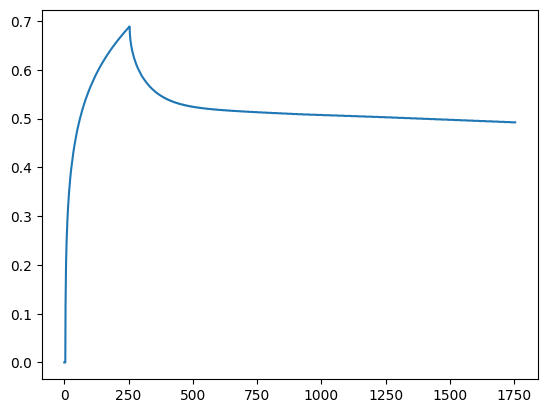

In [22]:
# plt.plot(data[:,100])
plt.plot(np.log1p(data[:,100])/3.48)


In [4]:
data=np.load('/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/2026_04_07_cfrp_multiple_fbh_and_tri_gauss_heat_5s_30s_45W_50fps.npz',allow_pickle=True)
data=torch.from_numpy(data['data']).float()

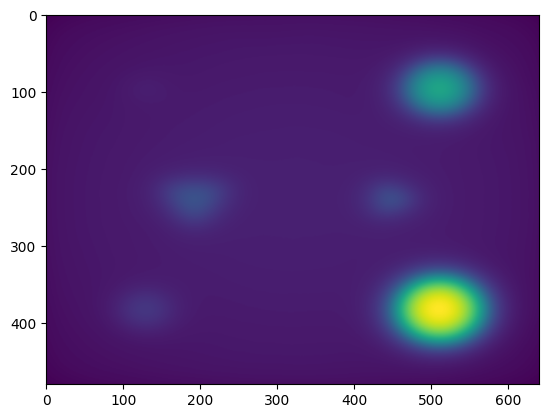

In [9]:
plt.imshow(data[400,:,:])

In [63]:
bfft=torch.fft.fft(torch.log1p(data[254:,380,:]),dim=0)
bfft.size()

torch.Size([1500, 640])

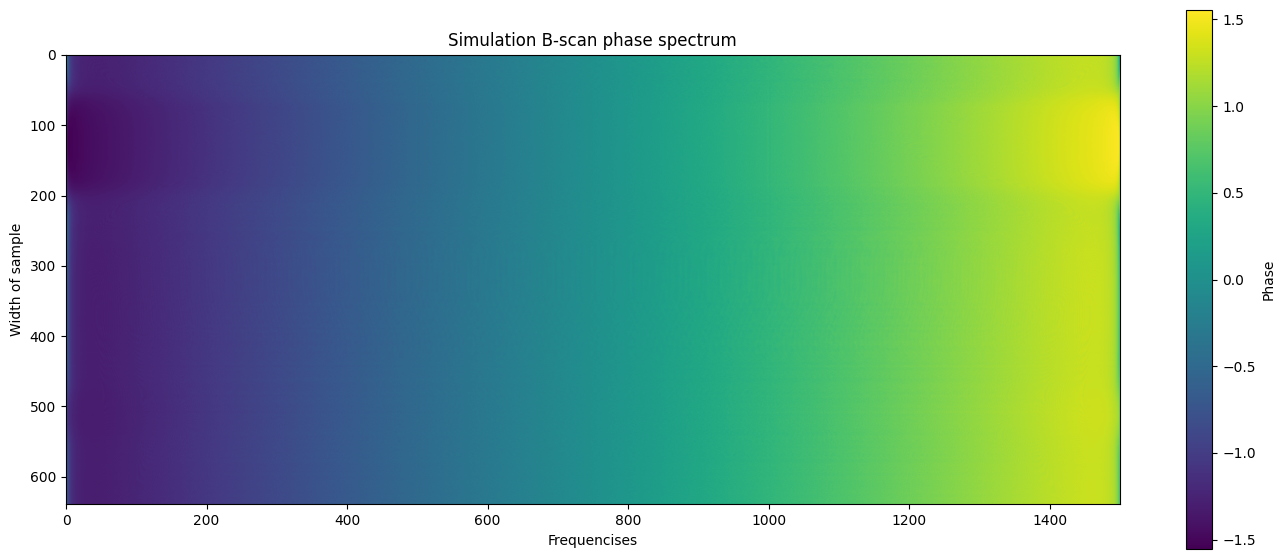

In [64]:
plt.figure(figsize=(17,10))
plt.imshow(np.rot90(torch.angle(bfft)))
plt.title('Simulation B-scan phase spectrum')
plt.xlabel('Frequencises')
plt.ylabel('Width of sample')
plt.colorbar(label='Phase',shrink=0.7)

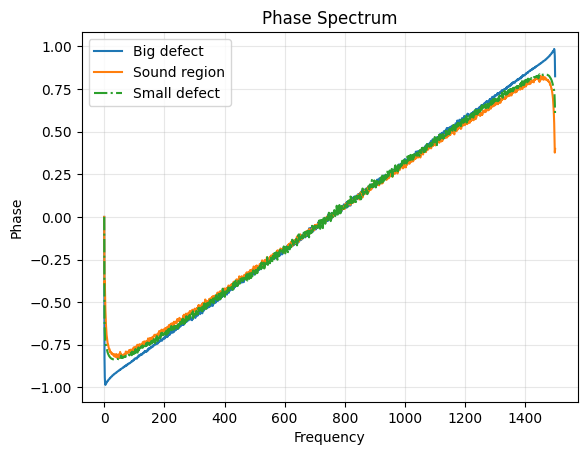

In [65]:
plt.plot(torch.angle(bfft[:,500])/(torch.pi/2),label='Big defect')
plt.plot(torch.angle(bfft[:,400])/(torch.pi/2),label='Sound region')
plt.plot(torch.angle(bfft[:,130])/(torch.pi/2),label='Small defect',linestyle='-.')
plt.xlabel('Frequency')
plt.ylabel('Phase')
plt.title('Phase Spectrum')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [66]:
phi = torch.angle(bfft)/(torch.pi/2)

phi_cos = torch.cos(phi)
phi_sin = torch.sin(phi)

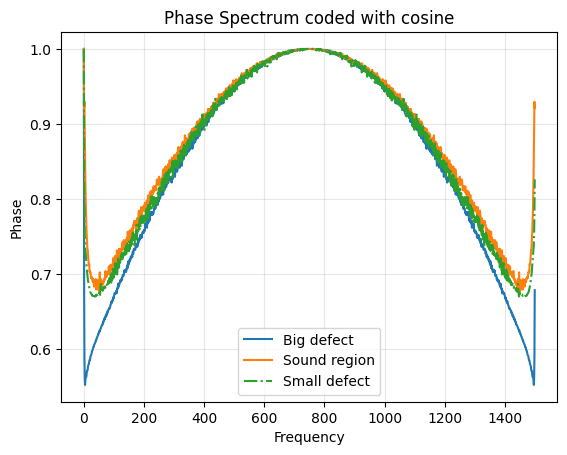

In [67]:
plt.plot(phi_cos[:,500],label='Big defect')
plt.plot(phi_cos[:,400],label='Sound region')
plt.plot(phi_cos[:,130],label='Small defect',linestyle='-.')
plt.xlabel('Frequency')
plt.ylabel('Phase')
plt.title('Phase Spectrum coded with cosine')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

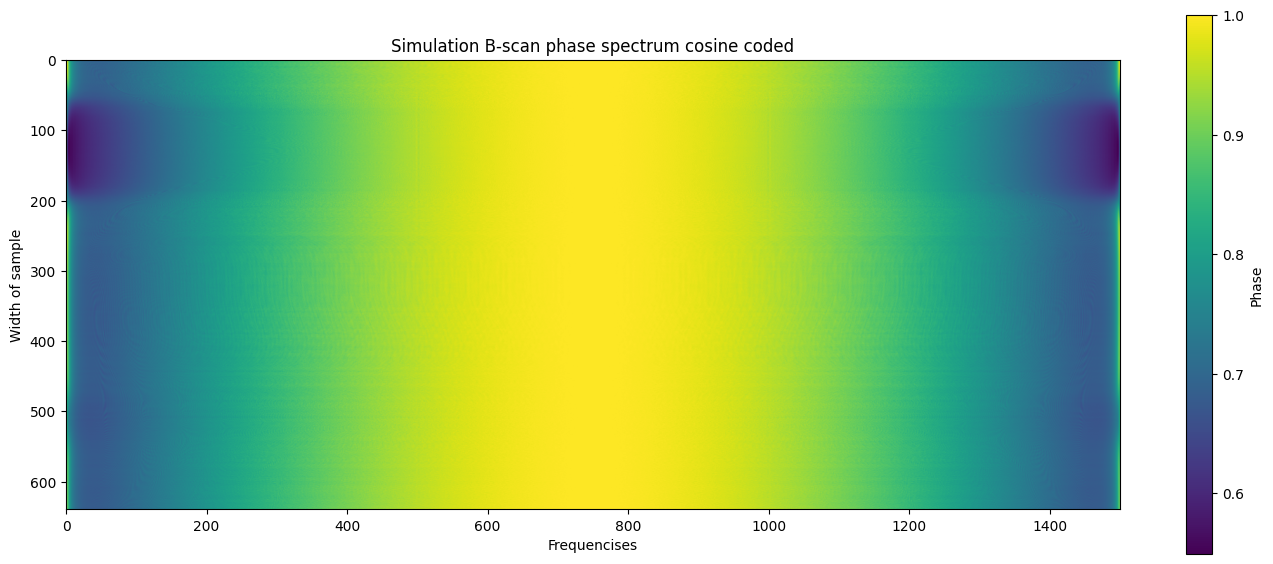

In [68]:
plt.figure(figsize=(17,10))
plt.imshow(np.rot90(phi_cos))
plt.title('Simulation B-scan phase spectrum cosine coded')
plt.xlabel('Frequencises')
plt.ylabel('Width of sample')
plt.colorbar(label='Phase',shrink=0.7)

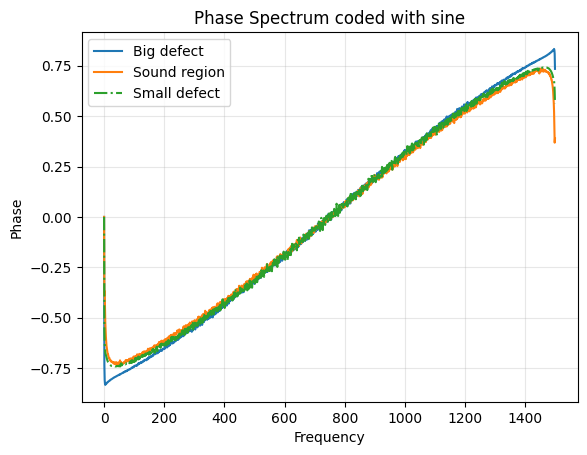

In [69]:
plt.plot(phi_sin[:,500],label='Big defect')
plt.plot(phi_sin[:,400],label='Sound region')
plt.plot(phi_sin[:,130],label='Small defect',linestyle='-.')
plt.xlabel('Frequency')
plt.ylabel('Phase')
plt.title('Phase Spectrum coded with sine')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

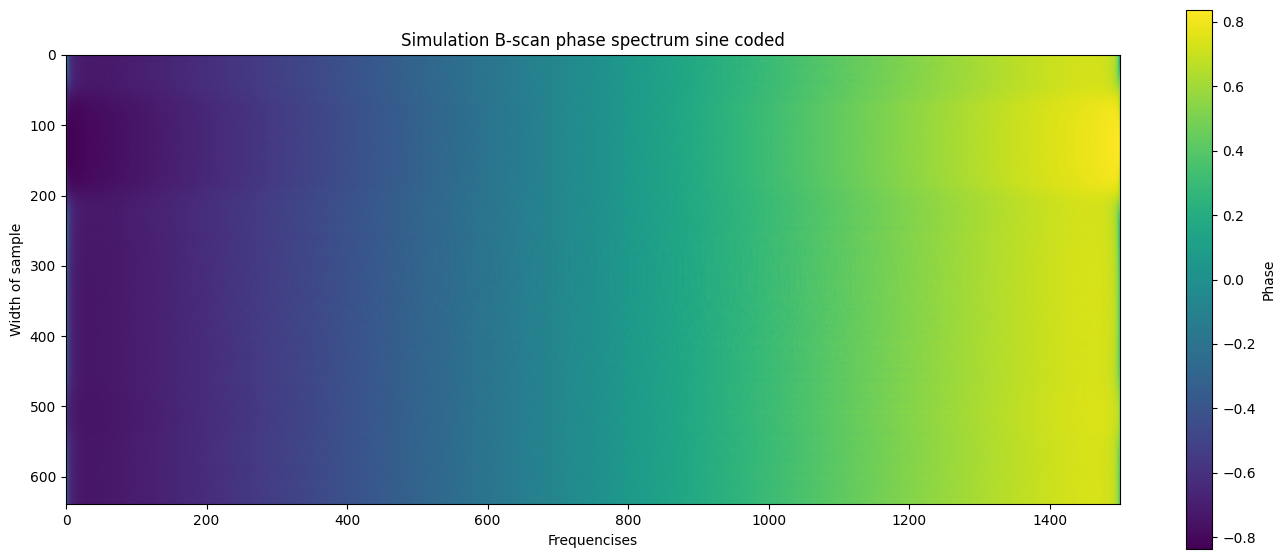

In [70]:
plt.figure(figsize=(17,10))
plt.imshow(np.rot90(phi_sin))
plt.title('Simulation B-scan phase spectrum sine coded')
plt.xlabel('Frequencises')
plt.ylabel('Width of sample')
plt.colorbar(label='Phase',shrink=0.7)